# FLUX.2 Klein Image Generation with OpenVINO™

The [FLUX.2 [klein]](https://blackforestlabs.ai/flux-2-klein/) model family are the fastest image models from [Black Forest Labs](https://blackforestlabs.ai/) to date. FLUX.2 [klein] unifies generation and editing in a single compact architecture, delivering state-of-the-art quality with end-to-end inference in as low as under a second.

<div>
<img src="https://huggingface.co/black-forest-labs/FLUX.2-klein-4B/resolve/main/realism.jpg" width="900">
</div>

<div>
<img src="https://huggingface.co/black-forest-labs/FLUX.2-klein-4B/resolve/main/editing.jpg" width="900">
</div>

**Key Features:**
1. Fastest distilled model for sub-second image generation
2. Text-to-image and image-to-image multi-reference editing in a single unified model
3. Runs on consumer GPUs (~13 GB VRAM for 4B, ~29 GB for 9B)
4. Supports 4-step inference with exceptional quality

The model comes in two variants:
- **FLUX.2 [klein] 4B** — 4 billion parameters, fully open under [Apache 2.0](https://www.apache.org/licenses/LICENSE-2.0) license. Compact but capable, built for local development, edge deployment, and production use.
- **FLUX.2 [klein] 9B** — 9 billion parameters, available under [FLUX Non-Commercial License](https://huggingface.co/black-forest-labs/FLUX.2-klein-9B/blob/main/LICENSE.md). Flagship small model that defines the Pareto frontier for quality vs. latency.

For more information, please read the [blog post](https://bfl.ai/blog/flux2-klein-towards-interactive-visual-intelligence).

In this notebook we demonstrate how to convert and optimize FLUX.2 [klein] using OpenVINO with INT4 weight compression.

> **Note**: This notebook requires at least 32 GB RAM for model conversion and ~16 GB for INT4 inference.


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/flux.2-klein/flux.2-klein.ipynb" />

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Select model](#Select-model)
- [Convert model with OpenVINO](#Convert-model-with-OpenVINO)
    - [Select weight format](#Select-weight-format)
    - [Export model using Optimum Intel](#Export-model-using-Optimum-Intel)
- [Run OpenVINO model inference](#Run-OpenVINO-model-inference)
    - [Text-to-Image](#Text-to-Image)
    - [Image Editing](#Image-Editing)
- [Interactive demo](#Interactive-demo)



## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [ ]:
import requests
from pathlib import Path

for fname in ("notebook_utils.py", "cmd_helper.py", "pip_helper.py"):
    if not Path(fname).exists():
        r = requests.get(
            url=f"https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/{fname}",
        )
        open(fname, "w").write(r.text)

from pip_helper import pip_install

%pip uninstall -q -y diffusers optimum-intel

pip_install(
    "-q",
    "gradio>=4.19,<6",
    "torch>=2.4",
    "nncf>=2.15.0",
    "transformers>=4.54.0,<5.0.0",
    "accelerate",
    "--extra-index-url",
    "https://download.pytorch.org/whl/cpu",
)
pip_install("-q", "git+https://github.com/huggingface/diffusers.git@153fcbc5a81be884304dcbe64986b7ea917a3802")
pip_install("-q", "git+https://github.com/huggingface/optimum-intel.git")
pip_install("-qU", "openvino>=2026.0")

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("flux.2-klein.ipynb")

## Select model
[back to top ⬆️](#Table-of-contents:)

FLUX.2 [klein] comes in two variants:
- **FLUX.2 [klein] 4B** — Apache 2.0 license, ~13 GB VRAM, built on a 4B flow model with 2.5B Qwen3 text embedder
- **FLUX.2 [klein] 9B** — Non-commercial license, ~29 GB VRAM, built on a 9B flow model with 8B Qwen3 text embedder

Both models are step-distilled to 4 inference steps and share the same architecture (Flux2KleinPipeline).

In [2]:
import ipywidgets as widgets

model_ids = ["black-forest-labs/FLUX.2-klein-4B", "black-forest-labs/FLUX.2-klein-9B"]

model_selector = widgets.Dropdown(
    options=model_ids,
    value=model_ids[0],
    description="Model:",
)

model_selector

Dropdown(description='Model:', options=('black-forest-labs/FLUX.2-klein-4B', 'black-forest-labs/FLUX.2-klein-9…

>**Note**: To run the **FLUX.2 [klein] 9B** model, you will need to accept the license agreement.
>You must be a registered user in 🤗 Hugging Face Hub. Please visit the [HuggingFace model card](https://huggingface.co/black-forest-labs/FLUX.2-klein-9B), carefully read the terms of the [FLUX Non-Commercial License](https://huggingface.co/black-forest-labs/LICENSE.md) and click the accept button. You will need to use an access token for the code below to run. For more information on access tokens, refer to [this section of the documentation](https://huggingface.co/docs/hub/security-tokens).
>
>The **FLUX.2 [klein] 4B** model is freely available under Apache 2.0 and does not require accepting a license agreement.
>
>You can login on Hugging Face Hub in the notebook environment using the following code:

In [3]:
# uncomment these lines to login to huggingfacehub to get access to pretrained model

# from huggingface_hub import notebook_login, whoami

# try:
#     whoami()
#     print('Authorization token already provided')
# except OSError:
#     notebook_login()

## Convert model with OpenVINO
[back to top ⬆️](#Table-of-contents:)

FLUX.2 [klein] uses a rectified flow transformer architecture. The pipeline consists of:

* **Text Encoder** — Qwen3 language model that creates conditioning embeddings from text prompts (stacked hidden states from intermediate layers).
* **Transformer** — Flux2Transformer2DModel for step-by-step denoising of the latent image representation.
* **VAE** — AutoencoderKLFlux2 for encoding/decoding between pixel and latent space.

We use [Optimum Intel](https://huggingface.co/docs/optimum/intel/index) to export all components to OpenVINO IR format.

### Select weight format
[back to top ⬆️](#Table-of-contents:)

INT4 weight compression significantly reduces model size and improves inference speed with minimal quality loss.

In [4]:
to_compress = widgets.Checkbox(
    value=True,
    description="INT4 weight compression",
    disabled=False,
)

to_compress

Checkbox(value=True, description='INT4 weight compression')

### Export model using Optimum Intel
[back to top ⬆️](#Table-of-contents:)

[Optimum Intel](https://huggingface.co/docs/optimum/intel/index) provides a simple interface to export and optimize models for OpenVINO.

In [5]:
from pathlib import Path

model_id = model_selector.value
model_base_dir = Path(model_id.split("/")[-1])
additional_args = {"task": "text-to-image"}

if to_compress.value:
    model_dir = model_base_dir / "INT4"
    # No compression flags beyond --weight-format so optimum-cli picks up the
    # registered per-component default (transformer/text_encoder INT4 + VAE INT8)
    # from optimum.intel.openvino.configuration._DEFAULT_4BIT_WQ_CONFIGS.
    additional_args.update({"weight-format": "int4"})
else:
    model_dir = model_base_dir / "FP16"
    additional_args.update({"weight-format": "fp16"})

print(f"Model ID: {model_id}")
print(f"Model will be exported to: {model_dir}")
print(f"Weight format: {'INT4' if to_compress.value else 'FP16'}")

Model ID: black-forest-labs/FLUX.2-klein-4B
Model will be exported to: FLUX.2-klein-4B\INT4
Weight format: INT4


In [6]:
from cmd_helper import optimum_cli

if not model_dir.exists():
    optimum_cli(model_id, model_dir, additional_args=additional_args)
else:
    print(f"Model already exists at {model_dir}, skipping export.")

**Export command:**

`optimum-cli export openvino --model black-forest-labs/FLUX.2-klein-4B FLUX.2-klein-4B\INT4 --task text-to-image --weight-format int4`

## Run OpenVINO model inference
[back to top ⬆️](#Table-of-contents:)

Select the device for running inference using OpenVINO. For Intel Arc GPUs, the pipeline automatically applies activation scaling to prevent FP16 overflow.

In [7]:
from notebook_utils import device_widget

device = device_widget(default="CPU", exclude=["NPU"])
device

Dropdown(description='Device:', options=('CPU', 'GPU', 'AUTO'), value='CPU')

In [12]:
from optimum.intel import OVFlux2KleinPipeline
import torch

ov_pipe = OVFlux2KleinPipeline.from_pretrained(
    model_dir,
    device=device.value,
)
print(f"Pipeline loaded from {model_dir}")

The `scaling_factor` attribute is missing from the VAE decoder configuration. Please re-export the model with newer version of optimum and diffusers.
The `scaling_factor` attribute is missing from the VAE encoder configuration. Please re-export the model with newer version of optimum and diffusers.


Pipeline loaded from FLUX.2-klein-4B\INT4


### Text-to-Image
[back to top ⬆️](#Table-of-contents:)

Generate an image from a text prompt. FLUX.2 Klein (distilled) works best with `guidance_scale=1.0` and `num_inference_steps=4`.

  0%|          | 0/4 [00:00<?, ?it/s]

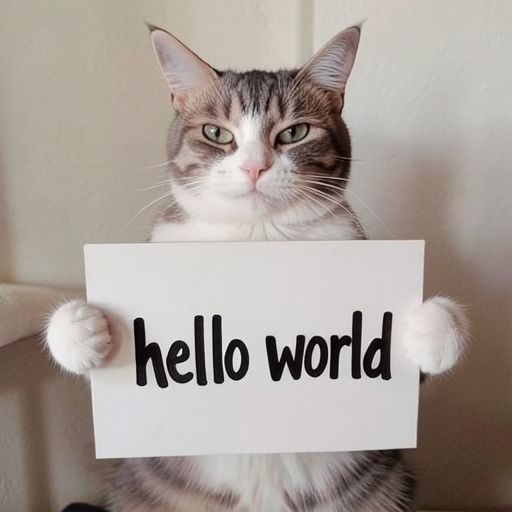

In [13]:
prompt = "A cat holding a sign that says hello world"

generator = torch.Generator("cpu").manual_seed(0)

result = ov_pipe(
    prompt=prompt,
    height=512,
    width=512,
    guidance_scale=1.0,
    num_inference_steps=4,
    generator=generator,
)

result.images[0]

### Image Editing
[back to top ⬆️](#Table-of-contents:)

FLUX.2 [klein] supports multi-reference image editing — you can pass one or more reference images along with a text prompt to guide generation. The model combines visual elements from the references with the text instruction.

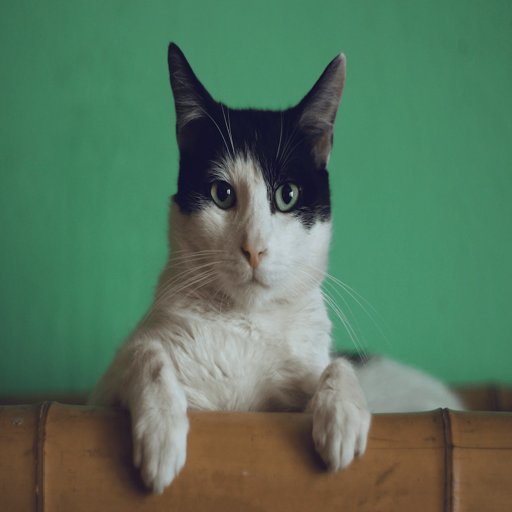

In [14]:
from PIL import Image
import urllib.request

# Download a sample image for editing demo
sample_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/cat.png"
sample_path = Path("sample_cat.png")
if not sample_path.exists():
    urllib.request.urlretrieve(sample_url, sample_path)  # nosec B310

ref_image = Image.open(sample_path).resize((512, 512))
ref_image

  0%|          | 0/4 [00:00<?, ?it/s]

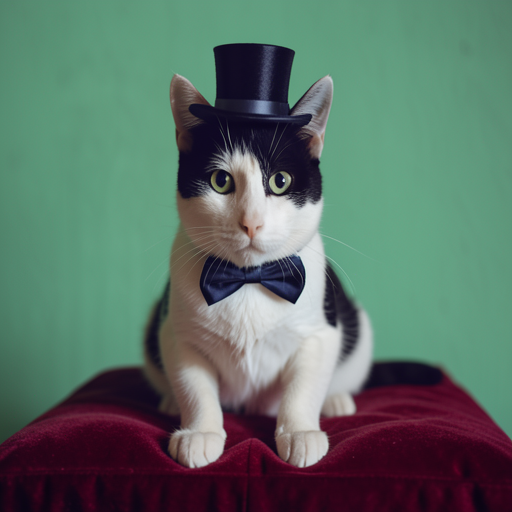

In [15]:
generator = torch.Generator("cpu").manual_seed(42)

result_edit = ov_pipe(
    prompt="A cat wearing a tiny top hat and bow tie, sitting on a velvet cushion",
    image=[ref_image],
    height=512,
    width=512,
    guidance_scale=1.0,
    num_inference_steps=4,
    generator=generator,
)

result_edit.images[0]

## Interactive demo
[back to top ⬆️](#Table-of-contents:)

In [ ]:
from gradio_helper import make_demo

demo = make_demo(ov_pipe)

try:
    demo.launch(debug=False)
except Exception:
    demo.launch(share=True, debug=False)

# If you are launching remotely, specify server_name and server_port:
# demo.launch(server_name='your server name', server_port='server port number')